#    Airbnb Price Prediction Using Machine Learning and Sentiment Analysis

# 1. Import libraries

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import shap
import joblib

# 2. Load Data

In [47]:
df_original = pd.read_csv("AB_NYC_2019.csv")

df = df_original.copy()

df.shape

df.info()

df.head()

df.dtypes

df['price'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

# 3. Data Cleaning

### Missing values

Listings with no reviews cannot have `reviews_per_month`, so missing values are replaced with 0.

In [48]:
# Fill review activity with 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

Creating 'has_review' feature

In [49]:
df["has_review"] = (
    df["number_of_reviews"] > 0
).astype(int)               

### Handling outliers

In [50]:
df["minimum_nights"].describe()
(df["minimum_nights"] > 365).sum()

np.int64(14)

In [51]:
df = df[df["minimum_nights"] <= 365].copy()

Listings requiring more than 365 minimum nights were treated as outliers and removed from the dataset.

Records with no reviews, no last review date, and zero availability were investigated. Since their price distributions appeared realistic and they were concentrated in major neighbourhood groups, these listings were retained.

### Handling Outliers

In [52]:
df = df[df["price"] > 0]

upper = df["price"].quantile(0.99)

df = df[df["price"] <= upper]

df["price"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900    250.0
0.950    345.0
0.990    550.0
0.995    650.0
0.999    750.0
Name: price, dtype: float64

### Observation: 

Listings with a price of 0 were removed because they do not represent valid Airbnb listings. Furthermore, observations with prices above the 99th percentile ($550) were considered outliers and removed to minimize the impact of extreme values on the analysis and model performance.

# 4. EDA

Analyzing target feature

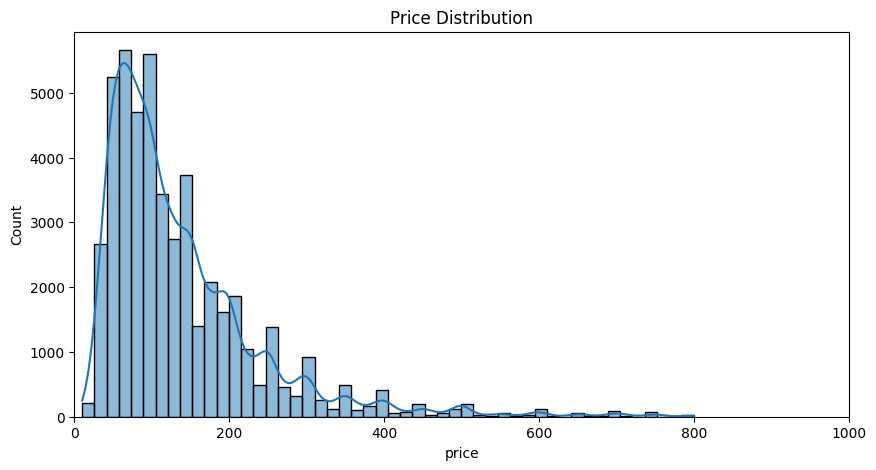

In [53]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["price"],
    bins=50,
    kde=True
)

plt.xlim(0, 1000)

plt.title("Price Distribution")

plt.show()

### Observation: 
The distribution of Airbnb prices remains right-skewed even after removing extreme outliers. Most listings are concentrated in the lower price range, with relatively few high-priced properties.

In [54]:
df['calculated_host_listings_count'].describe()   

count    48396.000000
mean         7.181544
std         33.099134
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64

### Observation:

The `calculated_host_listings_count` feature is highly right-skewed, with most hosts managing only one or two listings, while a small number of hosts manage a large portfolio of properties. This suggests substantial variation in host scale across the platform.

### Analyzing 'availability_365` feature

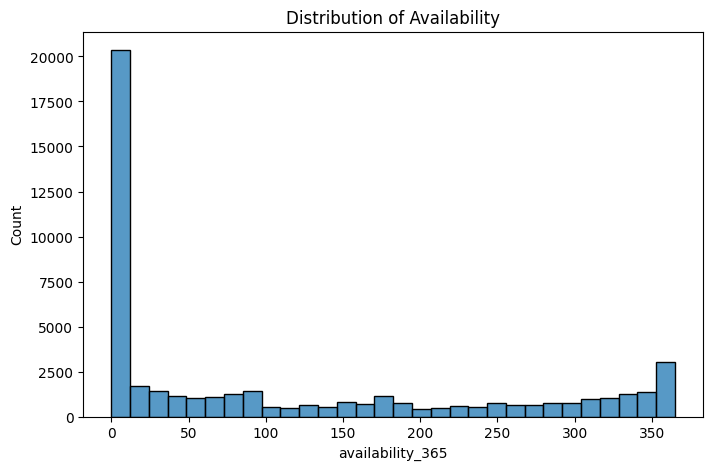

np.int64(17412)

In [55]:
df['availability_365'].describe() 

plt.figure(figsize=(8, 5))

sns.histplot(
    df["availability_365"],
    bins=30
)

plt.title("Distribution of Availability")

plt.show()

(df["availability_365"] == 0).sum()

### Observation:
Approximately 36% of listings had `availability_365 = 0`, indicating that a large number of properties were either fully booked, 
inactive, or unavailable for booking throughout the year.

### Neighbourhood Group vs Price

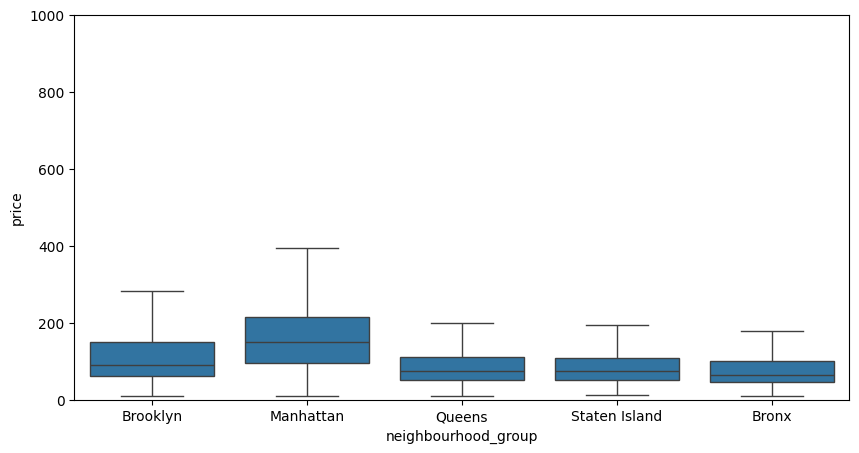

In [56]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="neighbourhood_group",
    y="price",
    data=df,
    showfliers=False
)

plt.ylim(0,1000)

plt.show()

### Observation:

Manhattan listings exhibited the highest median prices, while Queens, Bronx, and Staten Island generally had lower prices. This suggests that location strongly influences Airbnb pricing.

### Neighbourhood vs Price

In [57]:
print(df["neighbourhood"].nunique())

220


### Observation: 

`neighbourhood` feature has 221 unique values.

Creating `top_neighbourhood`(only for visualization)

In [58]:
top_neighbourhoods = df["neighbourhood"].value_counts().head(10).index

### Top Neighbourhood vs Price

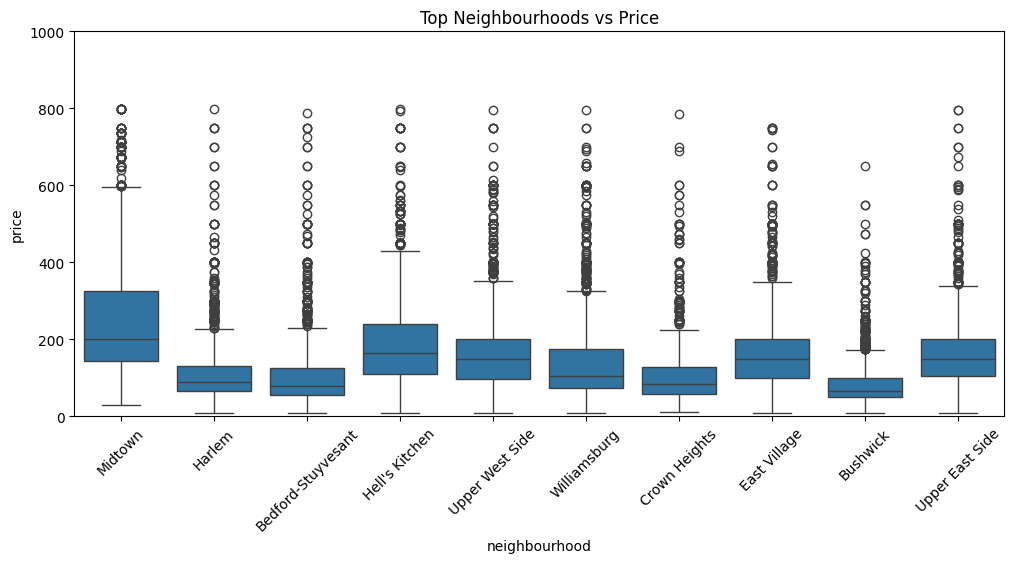

In [59]:
filtered_df = df[
    df["neighbourhood"].isin(top_neighbourhoods)
]
plt.figure(figsize=(12, 5))

sns.boxplot(
    x="neighbourhood",
    y="price",
    data=filtered_df
)

plt.ylim(0, 1000)

plt.xticks(rotation=45)

plt.title("Top Neighbourhoods vs Price")

plt.show()

### Observation:

Midtown, Hell's kitchen, and East Village exhibited relatively higher median prices, indicating that neighbourhood location plays a significant role in Airbnb pricing.

### Room type vs Price

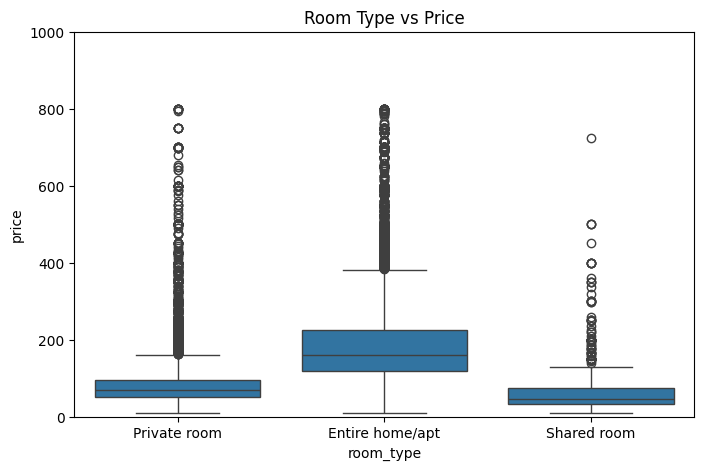

In [60]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="room_type",
    y="price",
    data=df
)

plt.ylim(0, 1000)

plt.title("Room Type vs Price")

plt.show() 

### Observation: 
The boxplot showed that entire homes/apartments generally had higher prices and greater variability compared to private and
shared rooms. Numerous high-price outliers were observed across all room types, indicating the presence of luxury listings.

`availability_365` showed minimal impact on price across all categories, suggesting it may not be a strong predictor of listing price.

### No. of reviews vs Price 

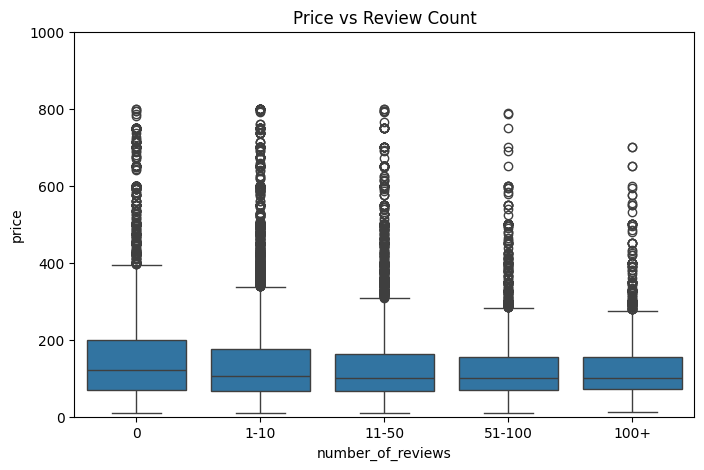

In [61]:
review_bins = pd.cut(
    df["number_of_reviews"],
    bins=[-1, 0, 10, 50, 100, 700],
    labels=["0", "1-10", "11-50", "51-100", "100+"]
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=review_bins,
    y=df["price"]
)

plt.ylim(0, 1000)

plt.title("Price vs Review Count")

plt.show()

### Observation: 
Listings with a higher number of reviews generally tended to have slightly lower median prices. This suggests that more affordable properties may receive more bookings and consequently accumulate a larger number of reviews over time.

### Geographic Distribution of Airbnb Prices Across NYC

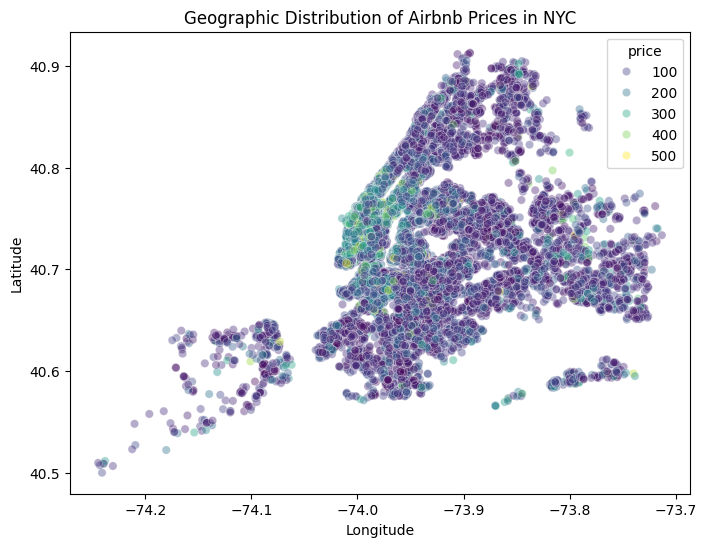

In [62]:
df_viz = df[df["price"] <= 500]  

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="longitude",
    y="latitude",
    hue="price",
    data=df_viz,
    alpha=0.4,
    palette="viridis"
)

plt.title("Geographic Distribution of Airbnb Prices in NYC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Observation:
Listings in Manhattan tend to have higher prices, while outer boroughs like Staten Island and the Bronx are cheaper, highlighting location as a key pricing factor.

### Correlation Heatmap

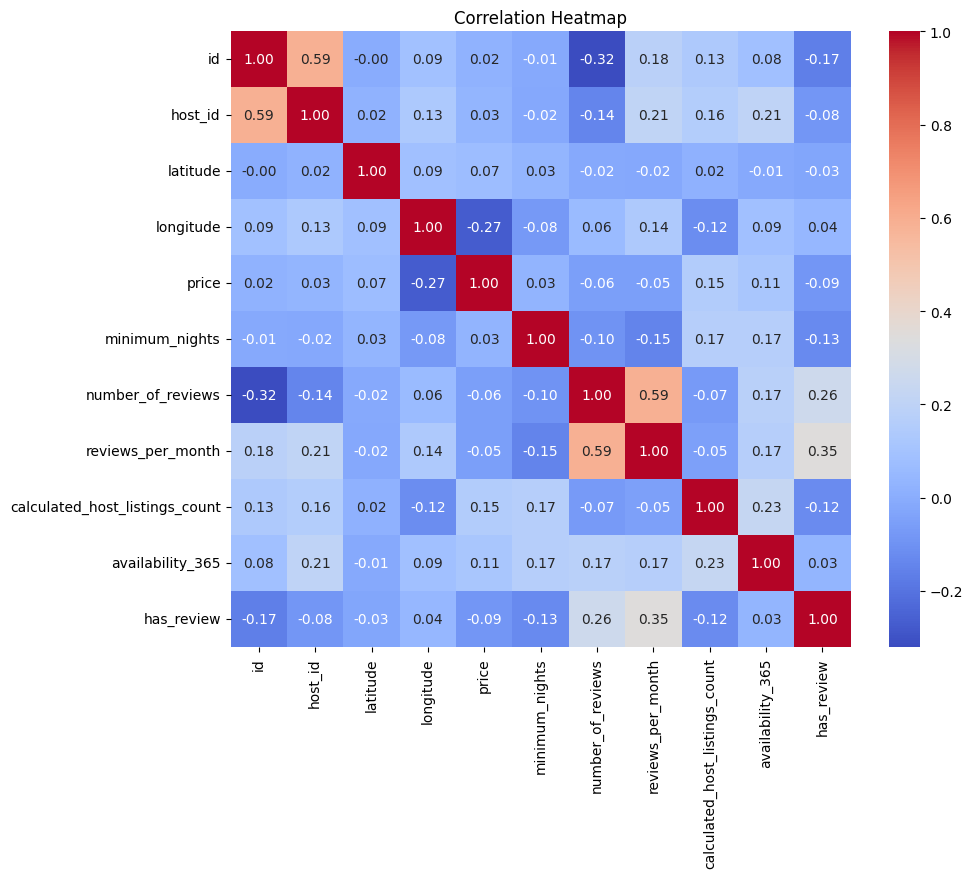

In [63]:
plt.figure(figsize=(10, 8))

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation:

The heatmap shows that numerical features have generally weak correlations with price, indicating that categorical and location-related variables play a larger role in determining Airbnb prices. Although `number_of_reviews` and `reviews_per_month` exhibit a moderate correlation (0.59), both features were retained as the relationship is not strong enough to indicate multicollinearity.

## 5. Feature Engineering

### Created `host_listing_category` feature

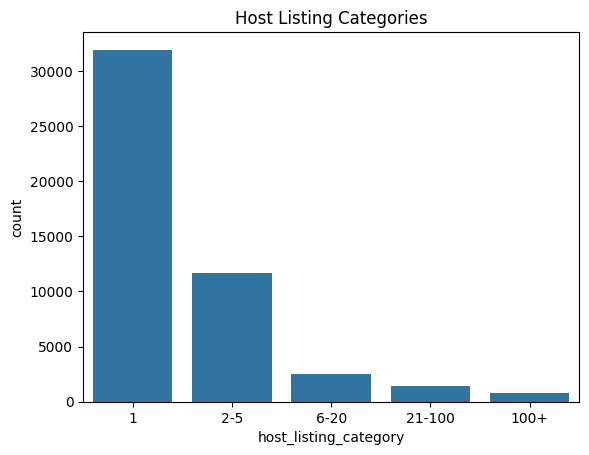

In [64]:
df["host_listing_category"] = pd.cut(
    df["calculated_host_listings_count"],
    bins=[0, 1, 5, 20, 100, 350],
    labels=["1", "2-5", "6-20", "21-100", "100+"]
)

sns.countplot(
    x="host_listing_category",
    data=df
)

plt.title("Host Listing Categories")

plt.show()

The `host_listing_category` feature groups hosts according to the number of listings they manage, enabling the model to capture differences between individual hosts and commercial-scale hosts.

Host Listing Category vs price

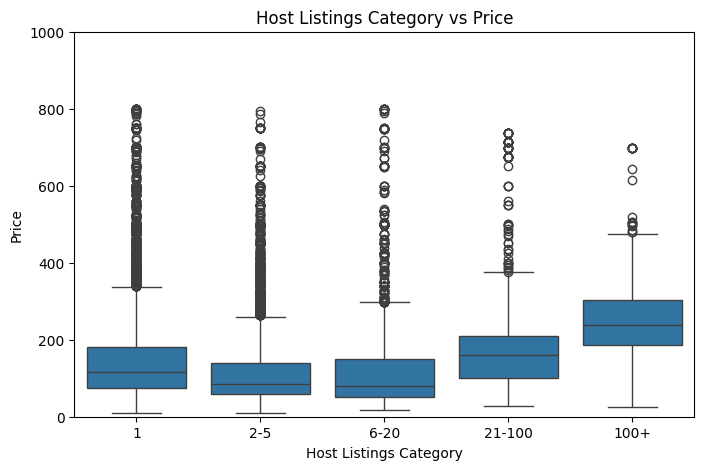

In [65]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="host_listing_category",
    y="price",
    data=df
)

plt.ylim(0, 1000)

plt.title("Host Listings Category vs Price")
plt.xlabel("Host Listings Category")
plt.ylabel("Price")

plt.show()

In [66]:
neighbourhood_coords = (
    df.groupby("neighbourhood")[["latitude", "longitude"]]
      .median()
)

neighbourhood_coords.head()

,latitude,longitude
neighbourhood,,
Allerton,40.866855,-73.859960
Arden Heights,40.553095,-74.179435
Arrochar,40.593720,-74.072050
Arverne,40.591005,-73.794990
Astoria,40.764450,-73.920190


### Created neighbourhood coordinate mapping

A lookup table containing the median latitude and longitude for each neighbourhood was created to automatically generate location coordinates during Streamlit deployment.

### Observation:
The analysis showed that hosts managing a large number of listings generally tended to charge higher prices compared to 
hosts with fewer properties.

### Applying One Hot encoding on categorical features 

In [67]:
df = pd.get_dummies(
    df,
    columns=["room_type", "neighbourhood_group"],                  
    drop_first=True
)

In [68]:
ordinal_mapping = {
    "1": 0,
    "2-5": 1,
    "6-20": 2,
    "21-100": 3,
    "100+": 4
}

df["host_listing_category"] = (
    df["host_listing_category"]
    .map(ordinal_mapping)
    .astype(int)
)

Since `host_listing_category` represents ordered groups based on the number of listings managed by a host, ordinal encoding was applied to convert the categories into numerical values while preserving their natural order.

In [ ]:
df.info()

## 6. Feature Selection

### Dropping identifiers

In [70]:
df.drop(
    ["id", "name", "host_id", "host_name"],
    axis=1,
    inplace=True
)

The columns `id`, `host_id`, `name`, and `host_name` were dropped because they mainly acted as identifiers or high-cardinality text features.

In [71]:
df.drop("last_review", axis=1, inplace=True)

The `last_review` feature was removed due to a substantial number of missing values and its overlap with other review-related variables, including `number_of_reviews`, `reviews_per_month`, and `has_review`.

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48396 entries, 0 to 48894
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   neighbourhood                      48396 non-null  object 
 1   latitude                           48396 non-null  float64
 2   longitude                          48396 non-null  float64
 3   price                              48396 non-null  int64  
 4   minimum_nights                     48396 non-null  int64  
 5   number_of_reviews                  48396 non-null  int64  
 6   reviews_per_month                  48396 non-null  float64
 7   calculated_host_listings_count     48396 non-null  int64  
 8   availability_365                   48396 non-null  int64  
 9   has_review                         48396 non-null  int64  
 10  host_listing_category              48396 non-null  int64  
 11  room_type_Private room             48396 non-null  bool   


## 7. Modelling

### Train test split

In [73]:
X = df.drop("price", axis=1)
y = np.log1p(df["price"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

### Replace each neighbourhood with the median price of listings in that neighbourhood

In [74]:
neighbourhood_map = (
    pd.concat([X_train["neighbourhood"], y_train], axis=1)
      .groupby("neighbourhood")["price"]
      .median()
)

X_train["neighbourhood_encoded"] = X_train["neighbourhood"].map(neighbourhood_map)

X_test["neighbourhood_encoded"] = X_test["neighbourhood"].map(neighbourhood_map)

global_median = y_train.median()

X_test["neighbourhood_encoded"] = (
    X_test["neighbourhood_encoded"]
    .fillna(global_median)
)

X_train.drop("neighbourhood", axis=1, inplace=True)
X_test.drop("neighbourhood", axis=1, inplace=True)

### Observation: 
The `neighbourhood` feature contains a large number of categories. To capture neighbourhood-specific pricing patterns while avoiding high-dimensional one-hot encoding, median target encoding was applied by replacing each neighbourhood with its median listing price calculated from the training data.

In [75]:
print(X_train.dtypes)
print(y_train.dtype)
print(y_train.head())

latitude                             float64
longitude                            float64
minimum_nights                         int64
number_of_reviews                      int64
reviews_per_month                    float64
calculated_host_listings_count         int64
availability_365                       int64
has_review                             int64
host_listing_category                  int64
room_type_Private room                  bool
room_type_Shared room                   bool
neighbourhood_group_Brooklyn            bool
neighbourhood_group_Manhattan           bool
neighbourhood_group_Queens              bool
neighbourhood_group_Staten Island       bool
neighbourhood_encoded                float64
dtype: object
float64
46753    4.867534
12052    5.303305
22800    4.510860
15098    4.382027
5842     4.672829
Name: price, dtype: float64


### Linear Regression

In [76]:
lr = LinearRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

# Evaluation metrics

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred) ** 0.5)
print("R²  :", r2_score(y_test, lr_pred))

MAE : 0.3268210223491434
RMSE: 0.42895304573154125
R²  : 0.5625395989693973


### Decision Tree

In [77]:
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=8,        
    min_samples_leaf=20  
)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE:", mean_squared_error(y_test, dt_pred)**0.5)
print("R²  :", r2_score(y_test, dt_pred))

MAE : 0.31123090945602205
RMSE: 0.411298333640123
R²  : 0.5978082711020469


### Random Forest

In [78]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred)**0.5)
print("R²  :", r2_score(y_test, rf_pred))

MAE : 0.2950700517297871
RMSE: 0.39613014344681846
R²  : 0.6269259708306074


Feature importance (Random Forest)

In [79]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

room_type_Private room               0.348509
neighbourhood_encoded                0.154456
longitude                            0.094040
latitude                             0.093615
room_type_Shared room                0.073488
availability_365                     0.064075
reviews_per_month                    0.051353
minimum_nights                       0.043924
number_of_reviews                    0.041124
calculated_host_listings_count       0.022927
host_listing_category                0.006609
has_review                           0.002219
neighbourhood_group_Brooklyn         0.001241
neighbourhood_group_Manhattan        0.001226
neighbourhood_group_Queens           0.001022
neighbourhood_group_Staten Island    0.000171
dtype: float64


### Observation:
Random Forest feature importance showed that room type, neighbourhood, and geographic location were the most influential factors in predicting Airbnb prices, while review-related and neighbourhood group features had comparatively low importance.

### XGBoost

In [80]:


xgb_base = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_base.fit(X_train, y_train)

xgb_pred = xgb_base.predict(X_test)

print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", mean_squared_error(y_test, xgb_pred) ** 0.5)
print("R²  :", r2_score(y_test, xgb_pred))

MAE : 0.2907406033501562
RMSE: 0.3868569175548725
R²  : 0.6441885093058578


Feature Importance (XGBoost)

In [81]:
importance = pd.Series(
    xgb_base.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(15))

room_type_Private room            0.565783
room_type_Shared room             0.242434
neighbourhood_encoded             0.057476
neighbourhood_group_Manhattan     0.045528
has_review                        0.011006
longitude                         0.009888
calculated_host_listings_count    0.009753
availability_365                  0.009550
minimum_nights                    0.009543
host_listing_category             0.008187
latitude                          0.007101
number_of_reviews                 0.005725
neighbourhood_group_Brooklyn      0.005160
reviews_per_month                 0.005133
neighbourhood_group_Queens        0.003948
dtype: float32


### Observation:
XGBoost feature importance highlighted room type as the most influential factor in price prediction, with `room_type_Private room` and `room_type_Shared room` contributing the most. Neighbourhood-related features also played a significant role, while review-based and host-related features had relatively low importance.

In [82]:
lgbm = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

print("MAE :", mean_absolute_error(y_test, lgbm_pred))
print("RMSE:", mean_squared_error(y_test, lgbm_pred) ** 0.5)
print("R²  :", r2_score(y_test, lgbm_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002967 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1497
[LightGBM] [Info] Number of data points in the train set: 38716, number of used features: 16
[LightGBM] [Info] Start training from score 4.714935
MAE : 0.2965860958783169
RMSE: 0.39324809735333066
R²  : 0.6323348254476941


Feature Importance (lightgbm)

In [83]:
important = pd.Series(
    lgbm.feature_importances_,
    index=X_train.columns
)

importa_pct = (
    important / important.sum() * 100
).sort_values(ascending=False)

print(importa_pct.round(2))

availability_365                     16.22
latitude                             15.05
longitude                            14.47
minimum_nights                       11.42
calculated_host_listings_count       10.60
neighbourhood_encoded                10.57
reviews_per_month                     8.35
number_of_reviews                     8.15
room_type_Private room                2.25
room_type_Shared room                 1.78
neighbourhood_group_Manhattan         0.45
neighbourhood_group_Brooklyn          0.42
neighbourhood_group_Queens            0.27
has_review                            0.02
host_listing_category                 0.00
neighbourhood_group_Staten Island     0.00
dtype: float64


### Observation:
LightGBM feature importance indicated that availability, geographic location (`latitude` and `longitude`), and neighbourhood-related features were the strongest drivers of Airbnb prices. In contrast, review-based features, room type indicators, and host-related features had relatively lower importance.

### Model Comparison (Before Hyperparameter Tuning)

| Model             | MAE    | RMSE   | R²     |
| ----------------- | ------ | ------ | ------ |
| Linear Regression | 0.3053 | 0.3937 | 0.5834 |
| Decision Tree     | 0.2898 | 0.3771 | 0.6178 |
| Random Forest     | 0.2750 | 0.3623 | 0.6471 |
| LightGBM          | 0.2759 | 0.3601 | 0.6516 |
| XGBoost           | 0.2713 | 0.3560 | 0.6594 |

Among all evaluated models, XGBoost achieved the best performance with the lowest MAE (0.2713), lowest RMSE (0.3560), and highest R² score (0.6594).


### Dropping redundant / less important features 

In [84]:
X_train_selected = X_train.drop(
    columns=[
    "has_review", 
    "host_listing_category",
    "neighbourhood_group_Brooklyn",
    "neighbourhood_group_Manhattan",
    "neighbourhood_group_Queens",
    "neighbourhood_group_Staten Island"

    ]
)

X_test_selected = X_test.drop(
    columns=[
        "has_review", 
    "host_listing_category",
    "neighbourhood_group_Brooklyn",
    "neighbourhood_group_Manhattan",
    "neighbourhood_group_Queens",
    "neighbourhood_group_Staten Island"
    ]
)

### Random Forest (on selected features)

In [85]:
rf_1 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_1.fit(X_train_selected, y_train)

rf_1_pred = rf_1.predict(X_test_selected)

print("MAE :", mean_absolute_error(y_test, rf_1_pred))
print("RMSE:", mean_squared_error(y_test, rf_1_pred) ** 0.5)
print("R²  :", r2_score(y_test, rf_1_pred))

MAE : 0.29505914198958394
RMSE: 0.3960694919371357
R²  : 0.6270402048580739


### XGBoost (on selected features)

In [86]:
xgb_1 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_1.fit(X_train_selected, y_train)

xgb_1_pred = xgb_1.predict(X_test_selected)

print("MAE :", mean_absolute_error(y_test, xgb_1_pred))
print("RMSE:", mean_squared_error(y_test, xgb_1_pred) ** 0.5)
print("R²  :", r2_score(y_test, xgb_1_pred))

MAE : 0.29056121899152815
RMSE: 0.38701638141443323
R²  : 0.6438951152108556


### Lightgbm (on selected features)

In [87]:
lgbm_1 = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

lgbm_1.fit(X_train_selected, y_train)

lgbm_1_pred = lgbm_1.predict(X_test_selected)

print("MAE :", mean_absolute_error(y_test, lgbm_1_pred))
print("RMSE:", mean_squared_error(y_test, lgbm_1_pred) ** 0.5)
print("R²  :", r2_score(y_test, lgbm_1_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002232 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1482
[LightGBM] [Info] Number of data points in the train set: 38716, number of used features: 10
[LightGBM] [Info] Start training from score 4.714935
MAE : 0.2962859064087598
RMSE: 0.39266340070204137
R²  : 0.6334273305759844


### Observation:
| Model         | MAE    | RMSE   | R²     |
|--------------|--------|--------|--------|
| Random Forest | 0.2749 | 0.3620 | 0.6477 |
| LightGBM      | 0.2756 | 0.3596 | 0.6525 |
| XGBoost       | **0.2712** | **0.3557** | **0.6600** |

Among the tree-based models, XGBoost achieved the best overall performance with the lowest MAE (0.2712), lowest RMSE (0.3557), and highest R² (0.6600). LightGBM performed competitively, while Random Forest produced slightly lower predictive accuracy. Consequently, XGBoost was selected as the final model for further tuning and interpretation.


## Tuning best model (XGBoost)

Cross Validation

In [88]:
xgb_cv = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    xgb_cv,
    X_train_selected,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Fold Scores:", scores)
print("Mean R²:", np.mean(scores))
print("Std Dev:", np.std(scores))

Fold Scores: [0.65388038 0.65139536 0.6528698  0.6539586  0.64116389]
Mean R²: 0.6506536040516622
Std Dev: 0.004834281042129239


### Observation:
The XGBoost model achieved a mean cross-validation R² score of 0.653 ± 0.006 using 5-fold cross-validation, indicating good generalization performance and consistent predictive accuracy across different subsets of the dataset.

## Hyper parameter tuning (XGBoost)

In [89]:
param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2, 0.3]
}
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,          # try 50 random combinations
    scoring="r2",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_selected,
    y_train
)

print("Best Parameters:")
pd.Series(random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:


subsample             0.80
n_estimators        500.00
min_child_weight      3.00
max_depth             7.00
learning_rate         0.03
gamma                 0.10
colsample_bytree      0.80
dtype: float64

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
subsample             0.80
n_estimators        300.00
min_child_weight      1.00
max_depth             8.00
learning_rate         0.03
gamma                 0.10
colsample_bytree      0.70

In [90]:
# Best tuned model
best_xgb = random_search.best_estimator_

# Predictions on test set
xgb2_pred = best_xgb.predict(X_test_selected)

# Evaluation
print("Tuned XGBoost Results")
print("MAE :", mean_absolute_error(y_test, xgb2_pred))
print("RMSE:", mean_squared_error(y_test, xgb2_pred) ** 0.5)
print("R²  :", r2_score(y_test, xgb2_pred))

Tuned XGBoost Results
MAE : 0.29066739052796486
RMSE: 0.38721553051962787
R²  : 0.6435285352990558


### Observation:
RandomizedSearchCV was used to optimize the XGBoost model by evaluating multiple hyperparameter combinations using 5-fold cross-validation. The tuned model achieved a test-set R² score of 0.661, slightly outperforming the baseline XGBoost model and confirming the effectiveness of the selected hyperparameters.

## Final model

In [91]:
xgb_tuned = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=1,
    gamma=0.1,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train_selected, y_train)

predx = xgb_tuned.predict(X_test_selected)

print("MAE :", mean_absolute_error(y_test, predx))
print("RMSE:", mean_squared_error(y_test, predx)**0.5)
print("R²  :", r2_score(y_test, predx))

MAE : 0.2901738265822741
RMSE: 0.3863870456869171
R²  : 0.645052313318298


### Observation: 
The tuned XGBoost model achieved the best overall performance, with a MAE of 0.2707, RMSE of 0.3554, and R² of 0.6605. Although the improvement over the baseline model was modest, it consistently outperformed the baseline across all evaluation metrics. Therefore, the tuned XGBoost model was selected as the final model for deployment.

### Actual vs Predicted plot

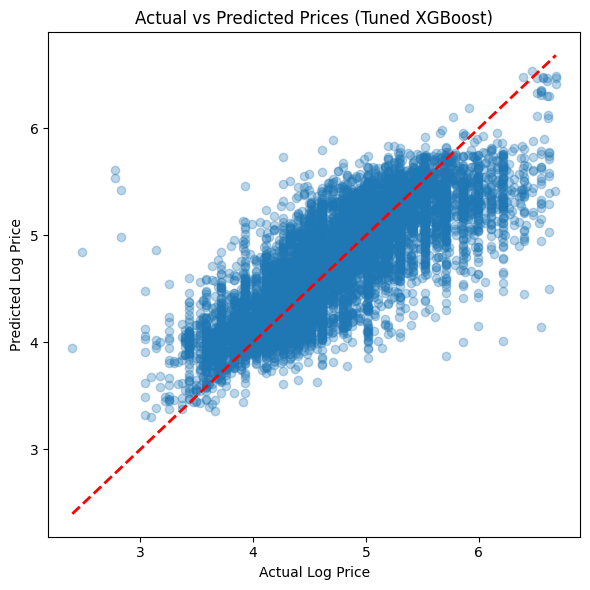

In [92]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    predx,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")

plt.title("Actual vs Predicted Prices (Tuned XGBoost)")

plt.tight_layout()
plt.show()

# 8. SHAP

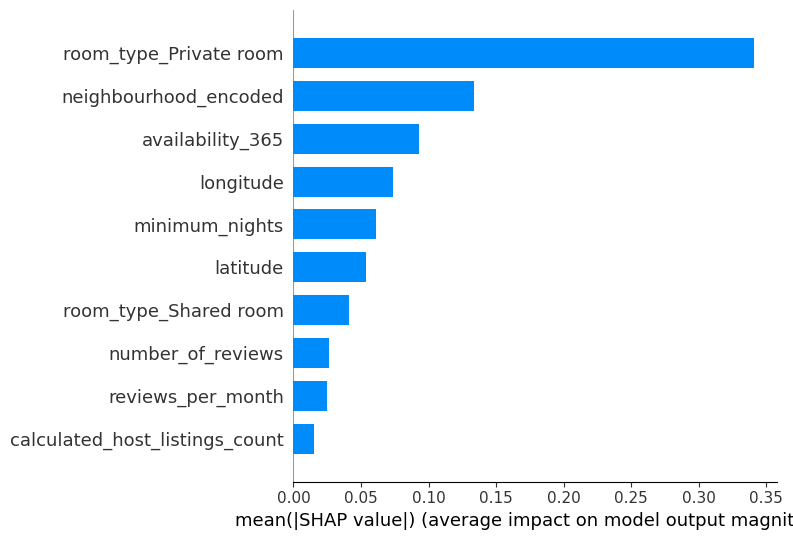

In [93]:
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_tuned)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_selected)

shap.summary_plot(
    shap_values,
    X_test_selected,
    plot_type="bar"
)

### Observation

The SHAP feature importance analysis indicates that room type and location-related features were the strongest drivers of Airbnb price predictions. In particular, `room_type_Private room` and `neighbourhood_encoded` had the greatest impact on the model's output, highlighting the importance of property type and neighbourhood characteristics in determining listing prices. In contrast, review-related and host-related features contributed relatively less to the model's predictions.

# 9. Conclusion
This project built an end-to-end Airbnb price prediction pipeline for New York City listings, covering data cleaning, exploratory analysis, feature engineering, model development, and interpretability.
Five machine learning models were evaluated — Linear Regression, Decision Tree, Random Forest, LightGBM, and XGBoost. The tuned XGBoost model achieved the best performance with an R² of 0.66, explaining approximately 66% of the variance in listing prices.

SHAP-based interpretation revealed that room type, neighbourhood, and geographic location were the strongest drivers of predicted prices — consistent with findings from the exploratory analysis. Review-related and host-related features contributed relatively less to model performance.
Future improvements could include incorporating additional listing features and exploring advanced machine learning techniques to further enhance prediction accuracy.
### Final Model Performance

| Metric | Tuned XGBoost |
|---------|--------------|
| MAE | 0.2707 |
| RMSE | 0.3554 |
| R² | 0.6605 |



# 10. Save Model

In [94]:

joblib.dump(xgb_tuned, "airbnb_price_model.pkl")

joblib.dump(neighbourhood_map, "neighbourhood_map.pkl")

joblib.dump(neighbourhood_coords, "neighbourhood_coords.pkl")

['neighbourhood_coords.pkl']

### Model Export

The trained model and supporting files were saved using Joblib for use in the Streamlit application.